In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print("Setup successful!")

Setup successful!


In [3]:
df = pd.read_csv("../data/SampleSuperstore.csv")

In [6]:
import os

print(os.getcwd())

c:\Users\Mili\Desktop\Retail-Sales-Analytics\notebooks


In [8]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [10]:
df.shape

(9994, 13)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


In [12]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

In [ ]:
#check for duplicate rows
df.duplicated().sum()
#contains 17 duplicate rows

np.int64(17)

In [14]:
#remove duplicates
df=df.drop_duplicates()

In [15]:
#verify duplicated removed
df.duplicated().sum()

np.int64(0)

In [ ]:
#till now
#Checked dataset structure using info()
#Verified data types
#Checked for missing values
#Identified 17 duplicate records
#Removed duplicate rows before analysis

In [16]:
df.shape

(9977, 13)

In [ ]:
#calculate bussiness kpis
total_sales=df['Sales'].sum()
total_profit=df["Profit"].sum()
total_orders=df.shape[0] #number of rows are number of orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)


Total Sales: 2296195.5903
Total Profit: 286241.42260000005
Total Orders: 9977


In [7]:
#region analysis
sales_by_region=df.groupby('Region')['Sales'].sum().reset_index()

In [24]:
sales_by_region.sort_values(by='Sales')

,Region,Sales
2,South,391721.9050
0,Central,500782.8528
1,East,678435.1960
3,West,725255.6365


In [8]:
profit_by_region=df.groupby('Region')['Profit'].sum().reset_index()

In [28]:
profit_by_region.sort_values(by='Profit', ascending=False)

,Region,Profit
3,West,108329.8079
1,East,91506.3092
2,South,46749.4303
0,Central,39655.8752


In [9]:
top_cities=df.groupby('City')['Sales'].sum().reset_index()

In [38]:
top_cities.sort_values(by='Sales',ascending=False)

,City,Sales
329,New York City,256319.041
266,Los Angeles,175831.901
452,Seattle,119460.282
438,San Francisco,112577.172
374,Philadelphia,109061.461
...,...,...
354,Ormond Beach,2.808
370,Pensacola,2.214
221,Jupiter,2.064
140,Elyria,1.824


In [36]:
top_citiesp=df.groupby('City')['Profit'].sum().reset_index()

In [42]:
top_citiesp.sort_values(by='Profit',ascending=False)

,City,Profit
329,New York City,62013.8973
266,Los Angeles,30431.4267
452,Seattle,29121.6825
438,San Francisco,17466.1186
123,Detroit,13146.6935
...,...,...
80,Chicago,-6648.3318
241,Lancaster,-7239.0684
434,San Antonio,-7299.0502
207,Houston,-10175.1755


In [12]:
top_cat=df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)

In [13]:
top_cat

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


In [14]:
top_catt=df.groupby('Category')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False)

In [15]:
top_catt

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


In [20]:
top_cat = df.groupby('Category')['Sales'].sum().reset_index()

top_catt = df.groupby('Category')['Profit'].sum().reset_index()

category_analysis = pd.merge(top_cat, top_catt, on='Category')

category_analysis['Profit Margin %'] = (
    category_analysis['Profit'] /
    category_analysis['Sales']
) * 100

category_analysis = category_analysis.sort_values(
    by='Profit Margin %',
    ascending=False
)

print(category_analysis)

          Category        Sales       Profit  Profit Margin %
2       Technology  836154.0330  145454.9481        17.395712
1  Office Supplies  719047.0320  122490.8008        17.035158
0        Furniture  741999.7953   18451.2728         2.486695


In [23]:
top_sub=df.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False).head(10)

In [24]:
top_sub

,Sub-Category,Sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


In [25]:
top_sub_profit=df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False).head(10)

In [26]:
top_sub_profit

,Sub-Category,Profit
6,Copiers,55617.8249
13,Phones,44515.7306
0,Accessories,41936.6357
12,Paper,34053.5693
3,Binders,30221.7633
5,Chairs,26590.1663
14,Storage,21278.8264
1,Appliances,18138.0054
9,Furnishings,13059.1436
7,Envelopes,6964.1767


In [30]:
low_sub=df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by='Profit').head(10)

In [31]:
low_sub

,Sub-Category,Profit
16,Tables,-17725.4811
4,Bookcases,-3472.5560
15,Supplies,-1189.0995
8,Fasteners,949.5182
11,Machines,3384.7569
10,Labels,5546.2540
2,Art,6527.7870
7,Envelopes,6964.1767
9,Furnishings,13059.1436
1,Appliances,18138.0054


In [33]:
salesvsprofit = df.groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

salesvsprofit = salesvsprofit.sort_values(
    by='Sales',
    ascending=False
)

print(salesvsprofit.head(10))

   Sub-Category        Sales      Profit
13       Phones  330007.0540  44515.7306
5        Chairs  328449.1030  26590.1663
14      Storage  223843.6080  21278.8264
16       Tables  206965.5320 -17725.4811
3       Binders  203412.7330  30221.7633
11     Machines  189238.6310   3384.7569
0   Accessories  167380.3180  41936.6357
6       Copiers  149528.0300  55617.8249
4     Bookcases  114879.9963  -3472.5560
1    Appliances  107532.1610  18138.0054


In [34]:
top_segment=df.groupby('Segment')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)

In [35]:
top_segment

,Segment,Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


In [36]:
top_segment_profit=df.groupby('Segment')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False)

In [37]:
top_segment_profit

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


In [38]:
top_segment=df.groupby('Segment')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)
top_segment_profit=df.groupby('Segment')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False)
segment_analysis = pd.merge(top_segment, top_segment_profit, on='Segment')

segment_analysis['Profit Margin %'] = (
    segment_analysis['Profit'] /
    segment_analysis['Sales']
) * 100

segment_analysis = segment_analysis.sort_values(
    by='Profit Margin %',
    ascending=False
)

print(segment_analysis)

       Segment         Sales       Profit  Profit Margin %
2  Home Office  4.296531e+05   60298.6785        14.034269
1    Corporate  7.061464e+05   91979.1340        13.025506
0     Consumer  1.161401e+06  134119.2092        11.548050


In [39]:
avg_dis_category=df.groupby('Category')['Discount'].mean().reset_index().sort_values(by='Discount',ascending=False)

In [40]:
avg_dis_category

,Category,Discount
0,Furniture,0.173923
1,Office Supplies,0.157285
2,Technology,0.132323


In [41]:
avg_dis_sub_category=df.groupby('Sub-Category')['Discount'].mean().reset_index().sort_values(by='Discount',ascending=False)

In [42]:
avg_dis_sub_category

,Sub-Category,Discount
3,Binders,0.372292
11,Machines,0.306087
16,Tables,0.261285
4,Bookcases,0.211140
5,Chairs,0.170178
1,Appliances,0.166524
6,Copiers,0.161765
13,Phones,0.154556
9,Furnishings,0.138349
8,Fasteners,0.082028


In [43]:
discount_profit = df.groupby('Discount')['Profit'].mean().reset_index()

discount_profit = discount_profit.sort_values(by='Discount')

print(discount_profit)

    Discount      Profit
0       0.00   66.900292
1       0.10   96.055074
2       0.15   27.288298
3       0.20   24.702572
4       0.30  -45.679636
5       0.32  -88.560656
6       0.40 -111.927429
7       0.45 -226.646464
8       0.50 -310.703456
9       0.60  -43.077212
10      0.70  -95.874060
11      0.80 -101.796797


In [45]:
loss_subcat = df.groupby('Sub-Category')['Profit'].sum().reset_index()

loss_subcat = loss_subcat.sort_values(
    by='Profit'
)

print(loss_subcat.head(10))

   Sub-Category      Profit
16       Tables -17725.4811
4     Bookcases  -3472.5560
15     Supplies  -1189.0995
8     Fasteners    949.5182
11     Machines   3384.7569
10       Labels   5546.2540
2           Art   6527.7870
7     Envelopes   6964.1767
9   Furnishings  13059.1436
1    Appliances  18138.0054


In [ ]:
high_discount_loss = df.groupby('Sub-Category').agg({
    'Discount':'mean',
    'Profit':'sum',
    'Sales':'sum'
}).reset_index()

high_discount_loss = high_discount_loss[
    (high_discount_loss['Discount'] >= 0.2) &
    (high_discount_loss['Profit'] < 0)
]

print(high_discount_loss.sort_values(by='Profit'))

   Sub-Category  Discount      Profit        Sales
16       Tables  0.261285 -17725.4811  206965.5320
4     Bookcases  0.211140  -3472.5560  114879.9963


In [1]:
import numpy as np


Mean Sales: 229.85800083049827
Median Sales: 54.489999999999995
Variance: 388395.5885424855
Standard Deviation: 623.2139187650461
25th Percentile: 17.28
50th Percentile: 54.489999999999995
75th Percentile: 209.94
90th Percentile: 572.7060000000001


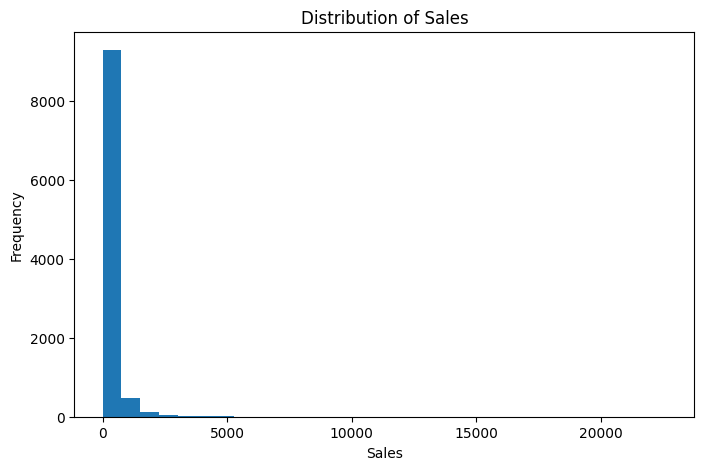

In [23]:
import numpy as np

sales = df['Sales']  

mean_sales = np.mean(sales)
median_sales = np.median(sales)
variance_sales = np.var(sales)
std_sales = np.std(sales)

p25 = np.percentile(sales, 25)
p50 = np.percentile(sales, 50)
p75 = np.percentile(sales, 75)
p90 = np.percentile(sales, 90)

print("Mean Sales:", mean_sales)
print("Median Sales:", median_sales)
print("Variance:", variance_sales)
print("Standard Deviation:", std_sales)
print("25th Percentile:", p25)
print("50th Percentile:", p50)
print("75th Percentile:", p75)
print("90th Percentile:", p90)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Sales'], bins=30)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

In [7]:
sales = df['Sales']  


In [9]:
#most preferred shipping mode
ship_orders = df['Ship Mode'].value_counts().reset_index()
ship_orders.columns = ['Ship Mode', 'Orders']
ship_orders

,Ship Mode,Orders
0,Standard Class,5968
1,Second Class,1945
2,First Class,1538
3,Same Day,543


In [11]:
ship_Sales = df.groupby('Ship Mode')['Sales'].sum().reset_index().sort_values(by='Sales',ascending=False)
ship_Sales

,Ship Mode,Sales
3,Standard Class,1.358216e+06
2,Second Class,4.591936e+05
0,First Class,3.514284e+05
1,Same Day,1.283631e+05


In [12]:
ship_profit = df.groupby('Ship Mode')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False)
ship_profit

,Ship Mode,Profit
3,Standard Class,164088.7875
2,Second Class,57446.6354
0,First Class,48969.8399
1,Same Day,15891.7589


In [1]:
import matplotlib.pyplot as plt

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Name: Profit, dtype: float64


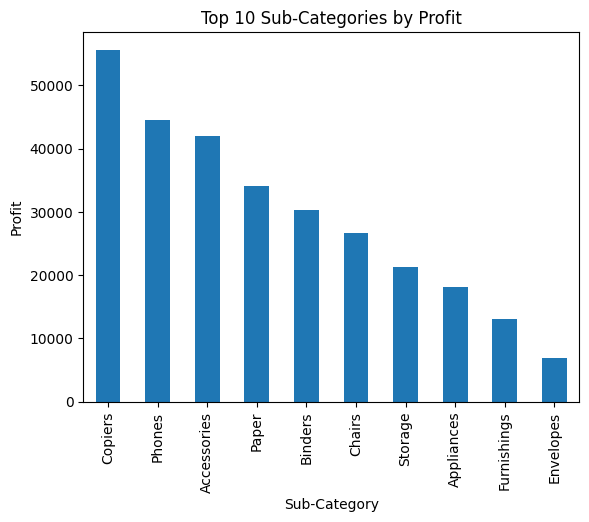

In [5]:
#2 6--graph by profit
import matplotlib.pyplot as plt

top_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_profit)

top_profit.plot(kind='bar')

plt.title('Top 10 Sub-Categories by Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.show()

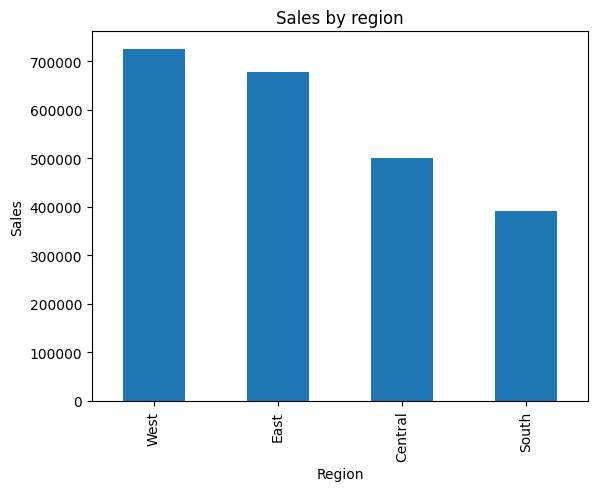

In [7]:
top_region=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
top_region.plot(kind='bar')
plt.title('Sales by region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

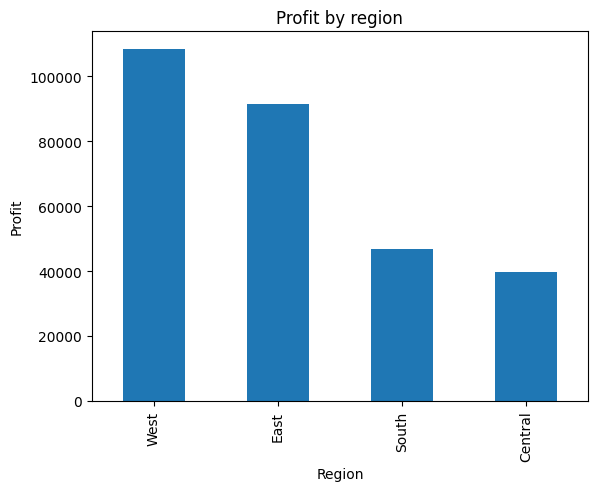

In [ ]:
top_profit_region=df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
plt.title('Profit by region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()


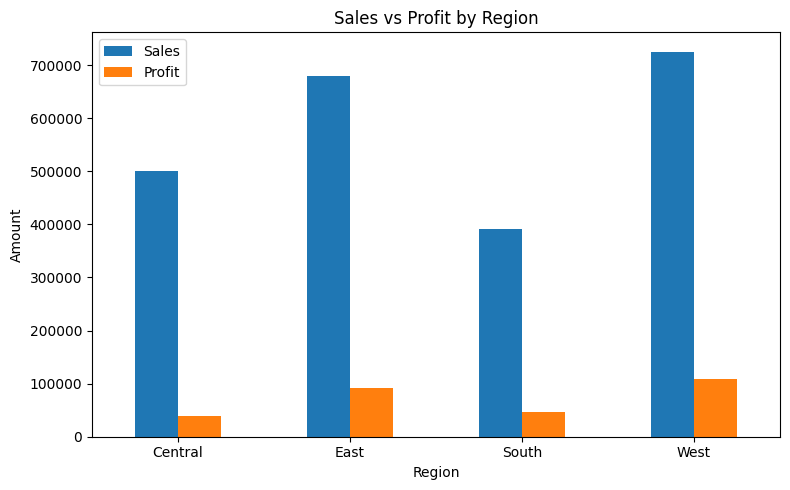

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

region_analysis.plot(
    x='Region',
    y=['Sales', 'Profit'],
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales vs Profit by Region')
plt.ylabel('Amount')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

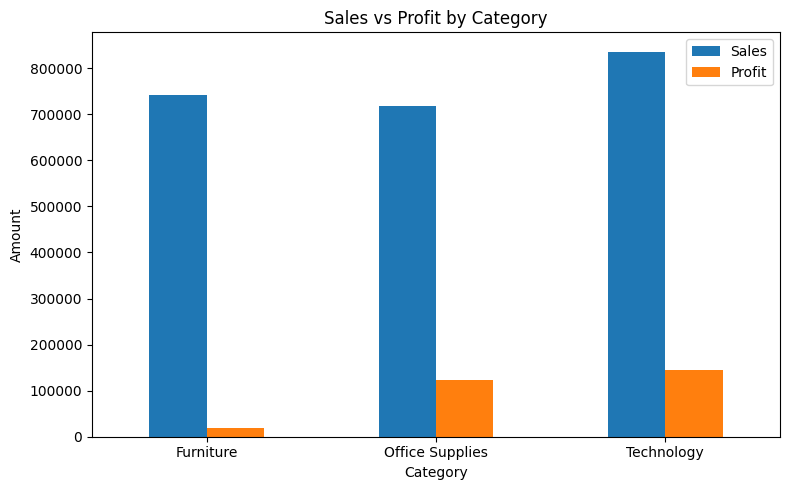

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

category_analysis.plot(
    x='Category',
    y=['Sales', 'Profit'],
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales vs Profit by Category')
plt.ylabel('Amount')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

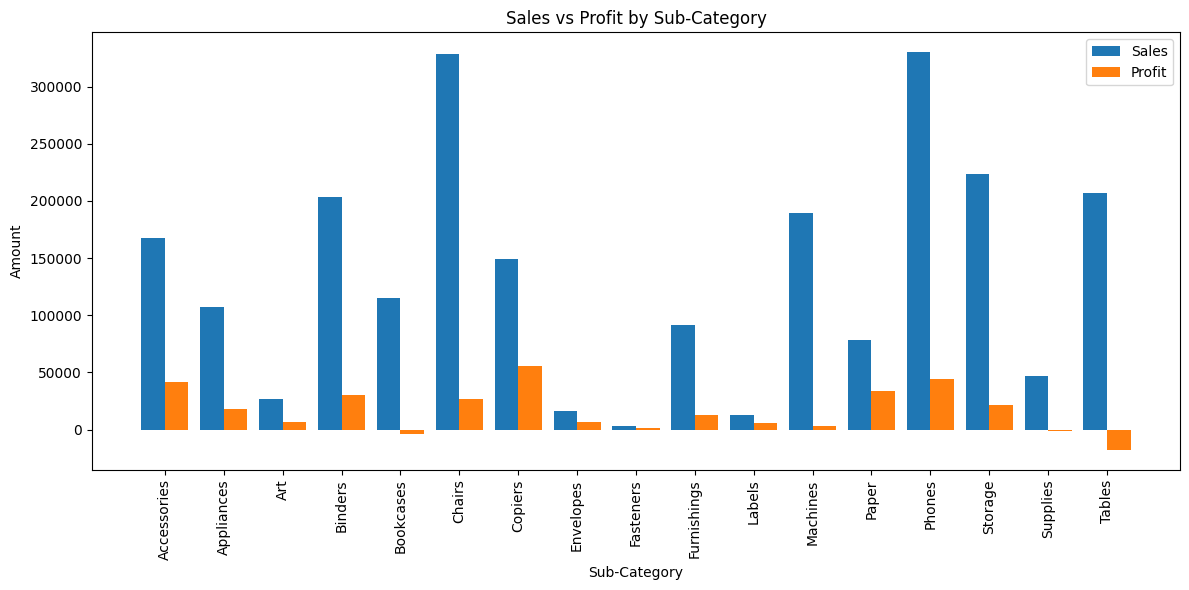

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sales_profit = df.groupby('Sub-Category')[['Sales','Profit']].sum().reset_index()

x = np.arange(len(sales_profit))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(x - width/2, sales_profit['Sales'], width, label='Sales')
plt.bar(x + width/2, sales_profit['Profit'], width, label='Profit')

plt.xticks(x, sales_profit['Sub-Category'], rotation=90)
plt.xlabel('Sub-Category')
plt.ylabel('Amount')
plt.title('Sales vs Profit by Sub-Category')
plt.legend()

plt.tight_layout()
plt.savefig("../images/sales_profit_subcategory.png", dpi=300, bbox_inches='tight')

plt.show()

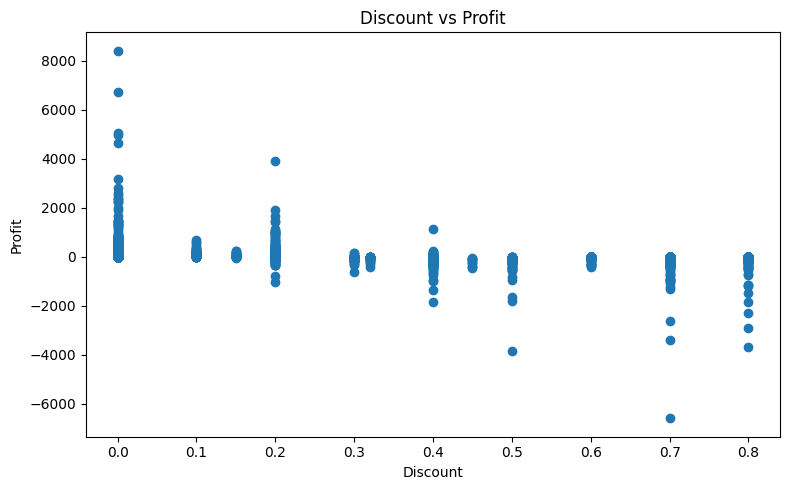

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Discount'],
    df['Profit']
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

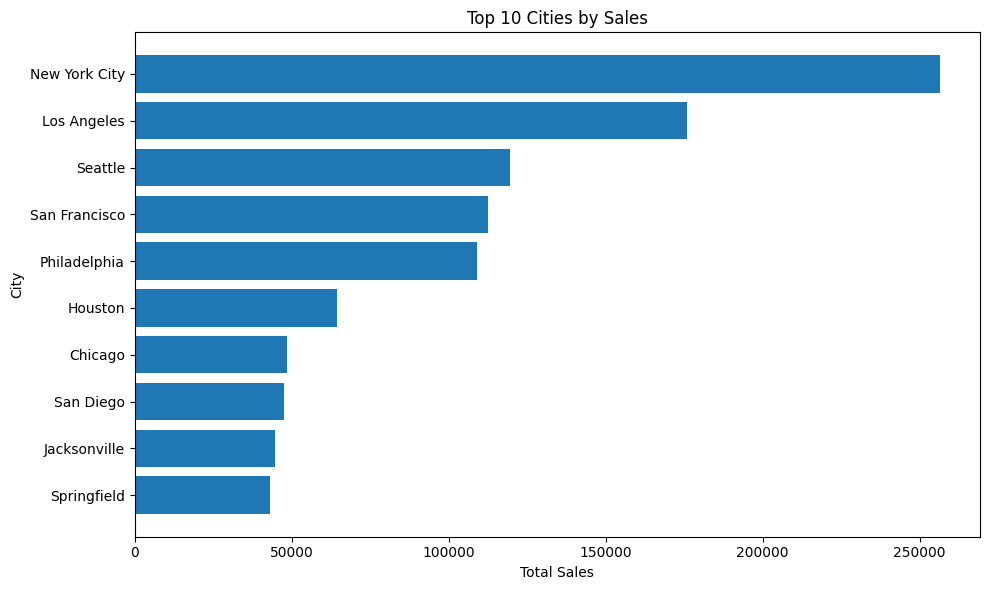

In [12]:
import matplotlib.pyplot as plt

top10_cities_sales = (
    df.groupby('City')['Sales']
    .sum()
    .reset_index()
    .sort_values(by='Sales', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(top10_cities_sales['City'],
         top10_cities_sales['Sales'])

plt.xlabel('Total Sales')
plt.ylabel('City')
plt.title('Top 10 Cities by Sales')

plt.gca().invert_yaxis()  # Highest sales city on top

plt.tight_layout()
plt.savefig("../images/top10_cities_sales.png", dpi=300, bbox_inches='tight')

plt.show()

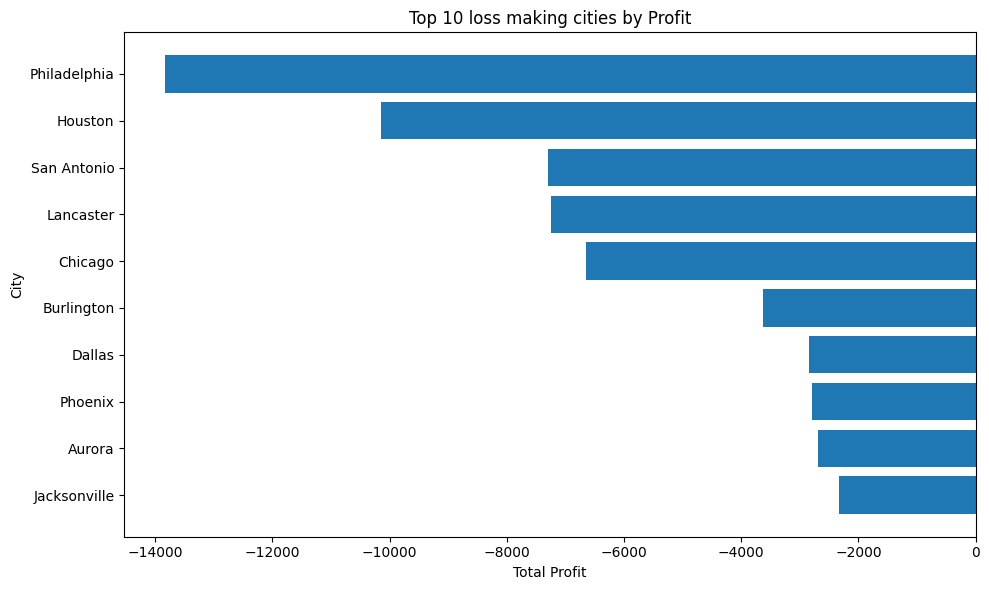

In [17]:
import matplotlib.pyplot as plt

top10_cities_sales = (
    df.groupby('City')['Profit']
    .sum()
    .reset_index()
    .sort_values(by='Profit')
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(top10_cities_sales['City'],
         top10_cities_sales['Profit'])

plt.xlabel('Total Profit')
plt.ylabel('City')
plt.title('Top 10 loss making cities by Profit')

plt.gca().invert_yaxis()  # Highest sales city on top

plt.tight_layout()
plt.show()

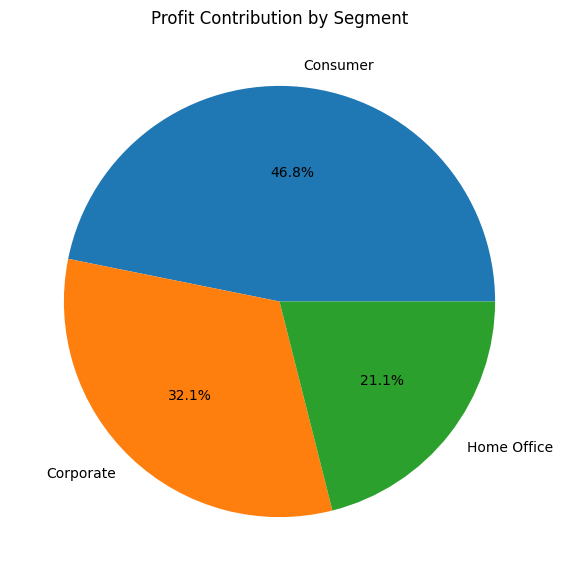

In [20]:

segment_profit = df.groupby('Segment')['Profit'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    segment_profit,
    labels=segment_profit.index,
    autopct='%1.1f%%'
)

plt.title('Profit Contribution by Segment')

plt.show()

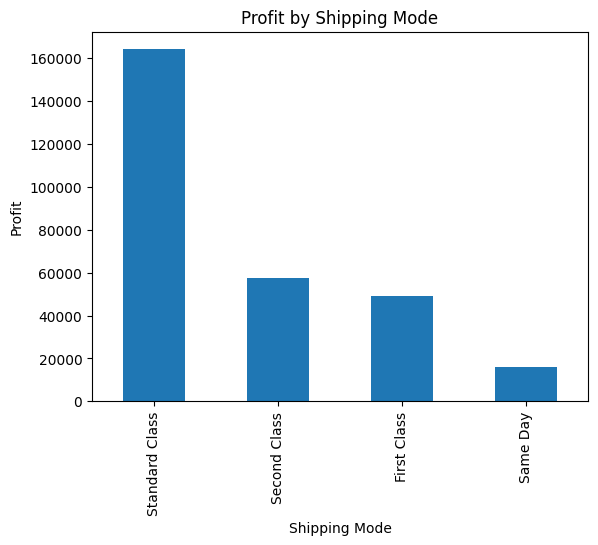

In [25]:
top_ship=df.groupby('Ship Mode')['Profit'].sum().sort_values(ascending=False)
top_ship.plot(kind='bar')
plt.title('Profit by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Profit')
plt.show()

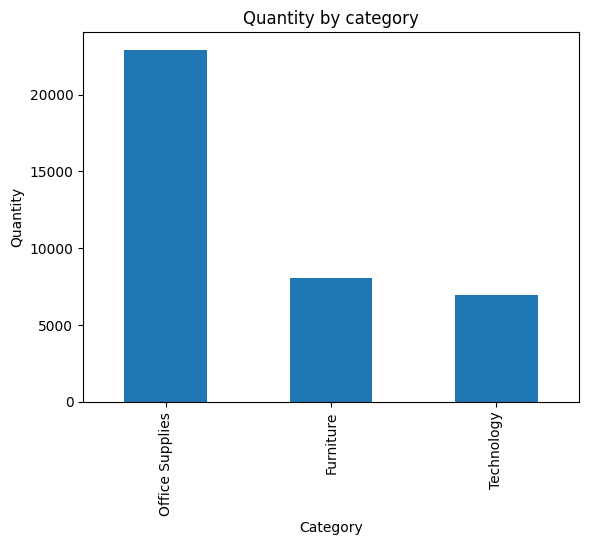

In [27]:
top_category=df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
top_category=df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
top_category.plot(kind='bar')
plt.title('Quantity by category')
plt.xlabel('Category')
plt.ylabel('Quantity')
plt.show()

In [8]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

print("Top 5 Profitable States")
print(state_profit.head())

print("\nBottom 5 States")
print(state_profit.tail())

Top 5 Profitable States
State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Name: Profit, dtype: float64

Bottom 5 States
State
North Carolina    -7490.9122
Illinois         -12607.8870
Pennsylvania     -15559.9603
Ohio             -16971.3766
Texas            -25729.3563
Name: Profit, dtype: float64


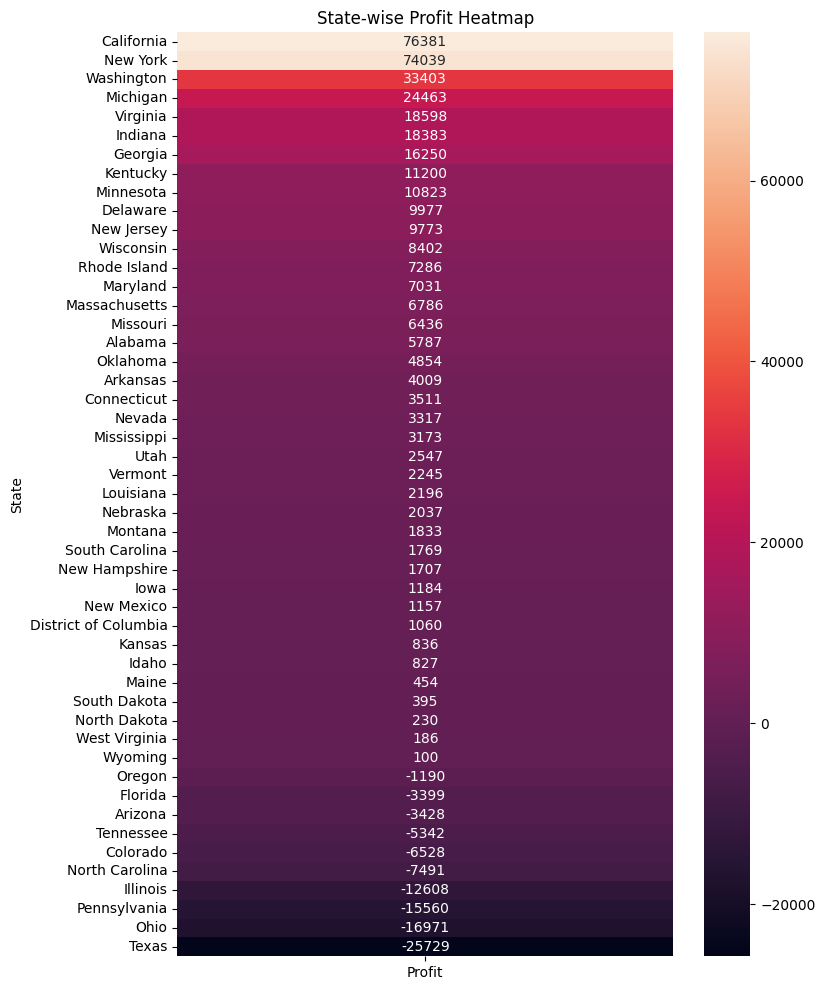

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

state_profit = (
    df.groupby('State')['Profit']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

heatmap_data = state_profit.set_index('State')

plt.figure(figsize=(8,12))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f'
)

plt.title('State-wise Profit Heatmap')
plt.savefig("../images/state_profit_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

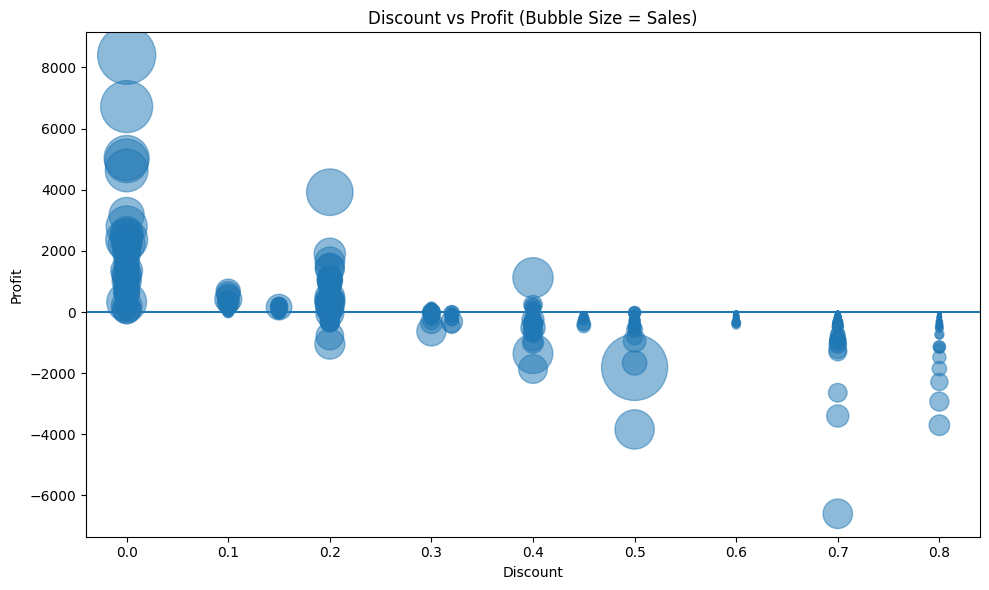

In [10]:
#Discount vs Profit Analysis 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['Discount'],
    df['Profit'],
    s=df['Sales']/10,   # bubble size
    alpha=0.5
)

plt.axhline(y=0)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit (Bubble Size = Sales)')

plt.tight_layout()
plt.savefig("../images/discount_profit_bubble.png", dpi=300, bbox_inches='tight')
plt.show()

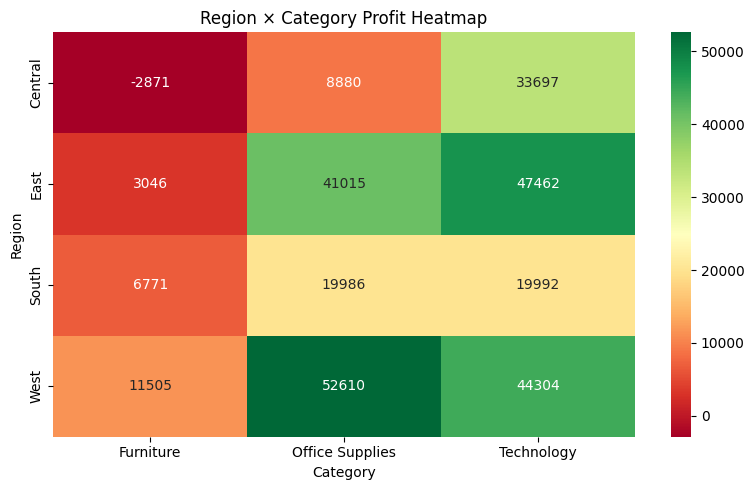

In [ ]:
#Region × Category Profit Heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn'
)

plt.title('Region × Category Profit Heatmap')

plt.tight_layout()
plt.savefig("../images/region_category_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

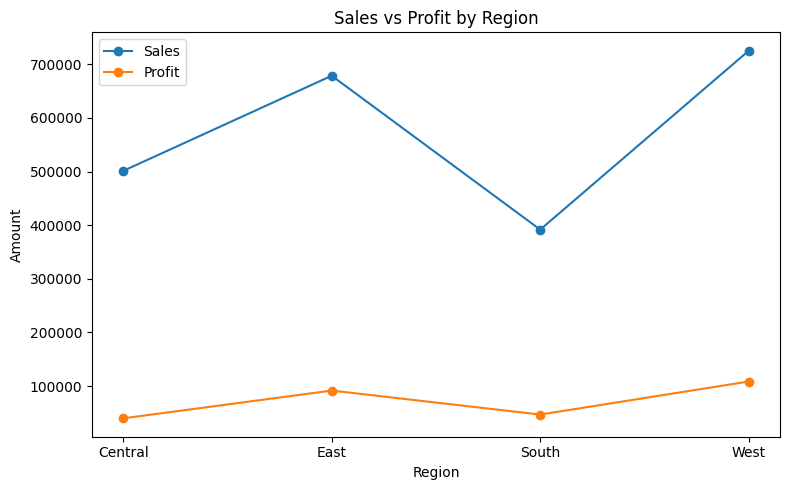

In [ ]:

import matplotlib.pyplot as plt

region_sp = (
    df.groupby('Region')[['Sales','Profit']]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    region_sp['Region'],
    region_sp['Sales'],
    marker='o',
    label='Sales'
)

plt.plot(
    region_sp['Region'],
    region_sp['Profit'],
    marker='o',
    label='Profit'
)

plt.xlabel('Region')
plt.ylabel('Amount')
plt.title('Sales vs Profit by Region')

plt.legend()

plt.tight_layout()
plt.show()


In [6]:
import os

print(os.getcwd())
print(os.path.exists("images"))

c:\Users\Mili\Desktop\Retail-Sales-Analytics\notebooks
False


In [7]:
import os
print(os.getcwd())

c:\Users\Mili\Desktop\Retail-Sales-Analytics\notebooks


In [8]:
import os
print(os.path.exists("../images"))

True
